# Visualização e Análise dos Resultados - Random Forest

Este notebook apresenta a análise visual dos resultados do modelo Random Forest, considerado o melhor preditor do tempo de entrega dos pedidos. Serão exploradas distribuições dos erros, comparação entre valores reais e previstos, e análise de feature importance.

In [1]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

## 1. Carregamento dos Dados e do Modelo

In [2]:
# Carregar os dados de teste e as previsões do Random Forest
# (Ajuste o caminho se necessário ou carregue os dados já preparados)
df = pd.read_csv('../data/olist_final_dataset.csv')

# features
features = ['total_price', 'freight_value', 'n_photos', 'total_volume', 'review_score', 'order_purchase_dayofweek', 'seller_state', 'customer_state', 'seller_city', 'customer_city', 'shipping_limit_days', 'payment_type', 'order_purchase_month', 'distance']
X = df[features]
y = df['delivery_time']

# Divisão entre treino e teste (80% treino, 20% teste)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
# Carregar modelo treinado (se salvo)
rf_model = joblib.load('../models/rf_model.pkl')
scaler = joblib.load('../models/scaler.pkl')

## 2. Previsões e Métricas

In [4]:
# Normalização dos dados usando o scaler salvo
X_test_scaled = scaler.transform(X_test)

# Previsão com o modelo Random Forest
y_pred = rf_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f} dias")
print(f"RMSE: {rmse:.2f} dias")
print(f"R²: {r2:.2%}")

MAE: 3.85 dias
RMSE: 6.75 dias
R²: 47.53%


## 3. Distribuição dos erros (Resíduos)

c:\ProgramData\Anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


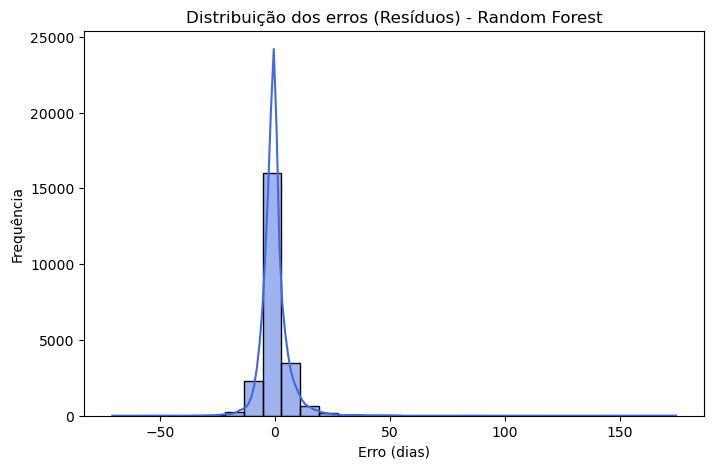

In [5]:
# Cálculo dos resíduos
erros = y_test - y_pred
plt.figure(figsize=(8,5))
sns.histplot(erros, bins=30, kde=True, color='royalblue')
plt.title('Distribuição dos erros (Resíduos) - Random Forest')
plt.xlabel('Erro (dias)')
plt.ylabel('Frequência')
plt.show()

## 4. Comparação: Valores reais vs. Previstos

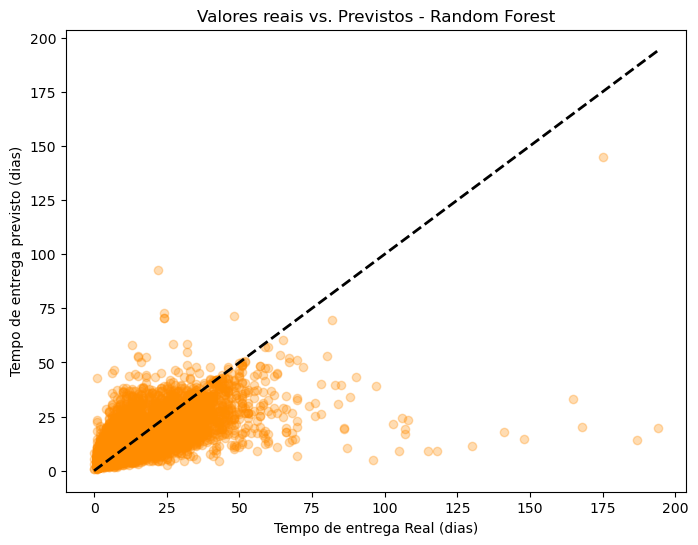

In [6]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.3, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Tempo de entrega Real (dias)')
plt.ylabel('Tempo de entrega previsto (dias)')
plt.title('Valores reais vs. Previstos - Random Forest')
plt.show()

## 5. Importância das features

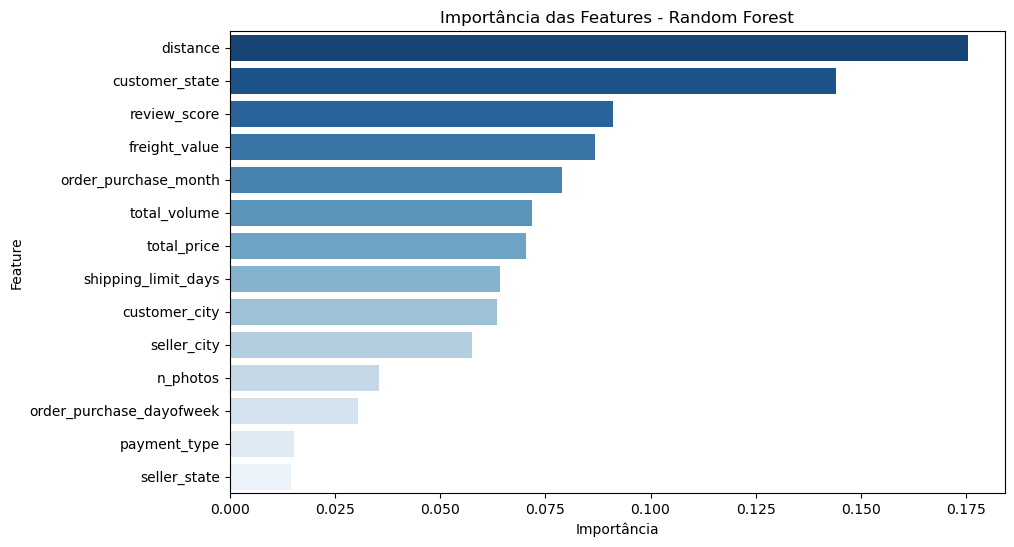

In [7]:
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='Blues_r')
plt.title('Importância das Features - Random Forest')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.show()

## 6. Considerações finais

O modelo Random Forest apresentou desempenho robusto na previsão do tempo de entrega dos pedidos, com métricas de erro e explicação da variância consistentes com a etapa de modelagem. As visualizações mostram que:

- A distribuição dos resíduos está centrada próxima de zero, indicando previsões sem viés sistemático relevante.
- A dispersão dos valores reais vs. previstos é razoável, mas há maior variabilidade para entregas muito longas, sugerindo possíveis outliers ou casos atípicos.
- As variáveis mais importantes para o modelo foram: distância, estado do cliente, review_score e valor do frete, reforçando a relevância de aspectos logísticos e regionais.

Apesar do bom desempenho, ainda há espaço para melhorias, como:
- Explorar novas features (ex: feriados, clima, sazonalidade).
- Analisar e tratar outliers/extremos.
- Testar outros modelos alternativos.